# Prática 6 - Incêndios Florestais
---
**Dupla:**
* Diane Fenzi Gonçalves (2019006574)
* Rubia Alice Moreira de Souza (2022043507)

## Imports
---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## Constantes
---

In [ ]:
CELULA_VAZIA = 0
CELULA_ARVORE = 1
CELULA_ARVORE_QUEIMADA = 2

## Criação da Rede
---

In [ ]:
def plotGrid(
    grid: list[list[int]],
    titulo: str = 'Simulação Incêndio Florestal'
  ) -> None:

  values = np.unique(grid.ravel())

  plt.figure(figsize = (8, 4))
  im = plt.imshow(grid)

  cmap = {
    0: [1.0, 1.0, 1.0 ,1],
    1: [0.0, 1.0, 0.0, 1],
    2: [1.0, 0.5, 0.1, 1]
  }
  labels = {0: 'Vazio', 1: 'Florestado', 2: 'Queimado'}
  arrayShow = np.array([[cmap[i] for i in j] for j in grid])
  patches = [mpatches.Patch(color = cmap[i], label = labels[i]) for i in cmap]

  plt.imshow(arrayShow)
  plt.title(titulo)
  plt.legend(handles = patches, loc = 4, borderaxespad = 0.)
  plt.show()

In [ ]:
def criarGrid(tamanho: int) -> list[list[int]]:
    linhas: int = int(np.sqrt(tamanho))
    colunas: int = int(np.sqrt(tamanho))

    return np.zeros((linhas, colunas), dtype = int)

In [ ]:
criarGrid(16)

array([[0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0]])

In [ ]:
def tentarCriarArvores(
    grid: list[list[int]],
    probabilidadeCrescerArvore: float
  ) -> list[list[int]]:

  for i in range(len(grid)):
    for j in range(len(grid[i])):
      if grid[i][j] != CELULA_VAZIA:
        continue

      if np.random.rand() < probabilidadeCrescerArvore:
        grid[i][j] = CELULA_ARVORE

  return grid

In [ ]:
def getVizinhoEsquerdo(i: int, j: int, rede):
  if(j == 0):
    return (i, len(rede[i]) - 1)

  return (i, j - 1)

In [ ]:
def getVizinhoDireito(i: int, j: int, rede):
  if(j == len(rede[i]) - 1):
    return (i, 0)

  return (i, j + 1)

In [ ]:
def getVizinhoAcima(i: int, j: int, rede):
  if(i == 0):
    return (len(rede) - 1, j)

  return (i - 1, j)

In [ ]:
def getVizinhoAbaixo(i: int, j: int, rede):
  if(i == len(rede) - 1):
    return (0, j)

  return (i + 1, j)

In [ ]:
def encontrarClusterArvoresIterativo(
    grid: list[list[int]],
    i: int,
    j: int
  ):

  pilhaArvores = []
  pilhaArvores.append((i, j))
  totalArvoresQueimadas = 0

  while len(pilhaArvores) > 0:
    i, j = pilhaArvores.pop()

    esquerdo = getVizinhoEsquerdo(i, j, grid)
    if grid[esquerdo[0]][esquerdo[1]] == CELULA_ARVORE:
      pilhaArvores.insert(0, esquerdo)
      grid[esquerdo[0]][esquerdo[1]] = CELULA_ARVORE_QUEIMADA
      totalArvoresQueimadas += 1

    direito = getVizinhoDireito(i, j, grid)
    if grid[direito[0]][direito[1]] == CELULA_ARVORE:
      pilhaArvores.insert(0, direito)
      grid[direito[0]][direito[1]] = CELULA_ARVORE_QUEIMADA
      totalArvoresQueimadas += 1

    acima = getVizinhoAcima(i, j, grid)
    if grid[acima[0]][acima[1]] == CELULA_ARVORE:
      pilhaArvores.insert(0, acima)
      grid[acima[0]][acima[1]] = CELULA_ARVORE_QUEIMADA
      totalArvoresQueimadas += 1

    abaixo = getVizinhoAbaixo(i, j, grid)
    if grid[abaixo[0]][abaixo[1]] == CELULA_ARVORE:
      pilhaArvores.insert(0, abaixo)
      grid[abaixo[0]][abaixo[1]] = CELULA_ARVORE_QUEIMADA
      totalArvoresQueimadas += 1

  return totalArvoresQueimadas

In [ ]:
def encontrarClusterArvoresRecursivo(
    grid: list[list[int]],
    i: int,
    j: int
  ):

  cluster = []

  esquerdo = getVizinhoEsquerdo(i, j, grid)
  if grid[esquerdo[0]][esquerdo[1]] == CELULA_ARVORE:
    cluster.append(esquerdo)
    grid[esquerdo[0]][esquerdo[1]] = CELULA_ARVORE_QUEIMADA

  direito = getVizinhoDireito(i, j, grid)
  if grid[direito[0]][direito[1]] == CELULA_ARVORE:
    cluster.append(direito)
    grid[direito[0]][direito[1]] = CELULA_ARVORE_QUEIMADA

  acima = getVizinhoAcima(i, j, grid)
  if grid[acima[0]][acima[1]] == CELULA_ARVORE:
    cluster.append(acima)
    grid[acima[0]][acima[1]] = CELULA_ARVORE_QUEIMADA

  abaixo = getVizinhoAbaixo(i, j, grid)
  if grid[abaixo[0]][abaixo[1]] == CELULA_ARVORE:
    cluster.append(abaixo)
    grid[abaixo[0]][abaixo[1]] = CELULA_ARVORE_QUEIMADA

  tamanhoCluster = len(cluster)

  for vizinho in cluster:
    tamanhoCluster += encontrarClusterArvoresRecursivo(grid, vizinho[0], vizinho[1])

  return tamanhoCluster

In [ ]:
def quedaRaio(
    grid: list[list[int]],
    probabilidadeQuedaRaio: float
  ) -> int:

  totalArvoresQueimadas: int = 0

  randomValue: float = np.random.rand()
  if randomValue >= 1 - probabilidadeQuedaRaio:
    return totalArvoresQueimadas

  i: int = np.random.randint(0, len(grid))
  j: int = np.random.randint(0, len(grid[i]))

  if grid[i][j] != CELULA_ARVORE:
    return totalArvoresQueimadas

  grid[i][j] = CELULA_ARVORE_QUEIMADA
  totalArvoresQueimadas = encontrarClusterArvoresIterativo(grid, i, j) + 1

  return totalArvoresQueimadas

## Simulações
---

In [ ]:
def passoTempo(
    grid: list[list[int]],
    probabilidadeCrescerArvore: float,
    probabilidadeQuedaRaio: float
  ) -> int:

  tentarCriarArvores(grid, probabilidadeCrescerArvore)
  totalArvoresQueimadas = quedaRaio(grid, probabilidadeQuedaRaio)
  return totalArvoresQueimadas

In [ ]:
def simular(
    quantidadeSimulacoes: int,
    tamanho: int,
    probabilidadeCrescerArvore: float,
    probabilidadeQuedaRaio: float,
    devePlotar: bool = False
  ) -> list[int]:

  grid = criarGrid(tamanho)
  if devePlotar:
    plotGrid(grid)

  contagemArvoresQuimadas: list[int] = []

  for i in range(quantidadeSimulacoes):
    totalArvoresQueimadas = passoTempo(
      grid,
      probabilidadeCrescerArvore,
      probabilidadeQuedaRaio
    )

    if devePlotar:
      plotGrid(grid)

    contagemArvoresQuimadas.append(totalArvoresQueimadas)

  return contagemArvoresQuimadas

### Exploração dos Parâmetros
---

#### Crescimento e queda de raio baixas
---

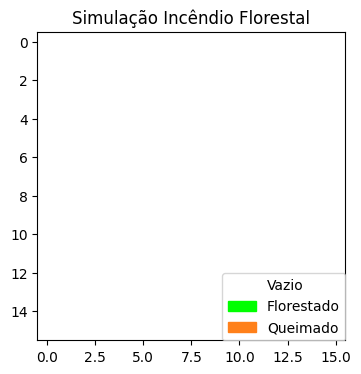

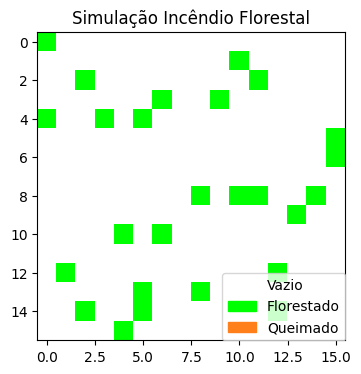

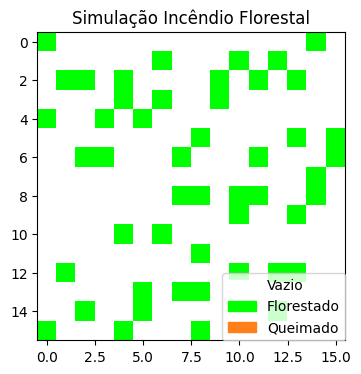

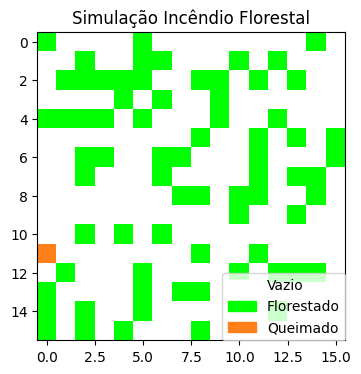

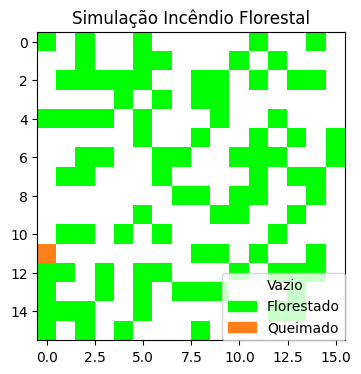

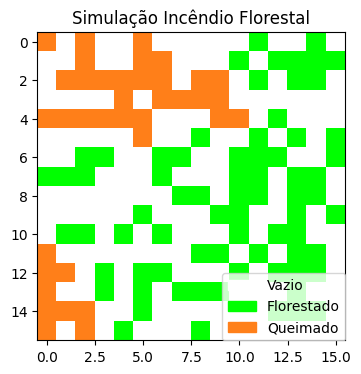

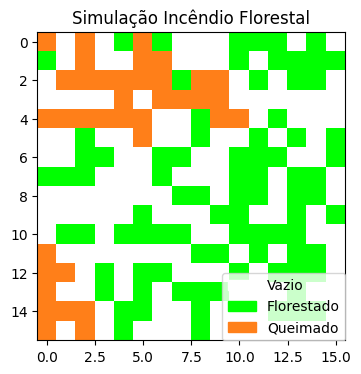

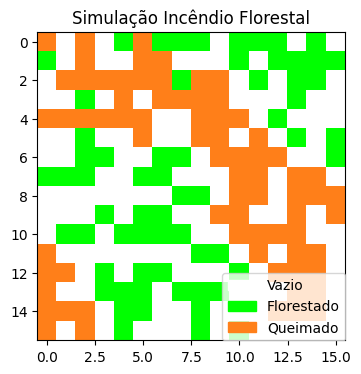

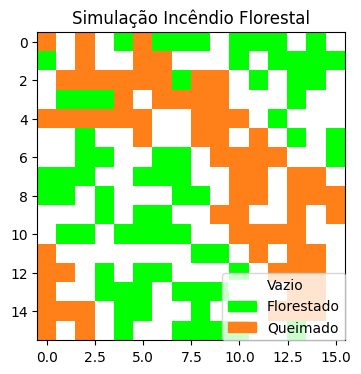

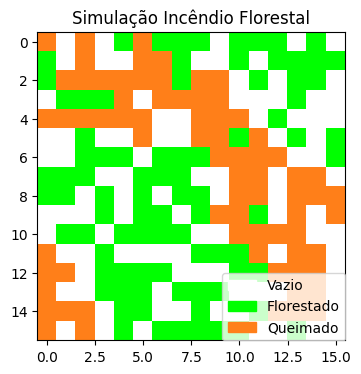

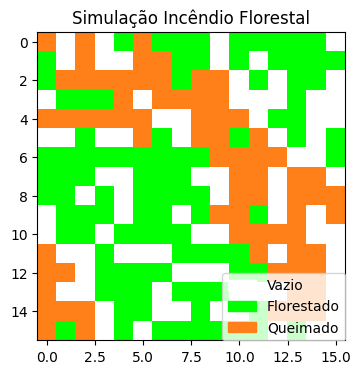

[0, 0, 1, 0, 36, 0, 36, 0, 0, 0]

In [ ]:
simular(
    quantidadeSimulacoes = 10,
    tamanho = 256,
    probabilidadeCrescerArvore = 0.1,
    probabilidadeQuedaRaio = 0.2,
    devePlotar = True
)

#### Crescimento alto e queda de raio baixa
---

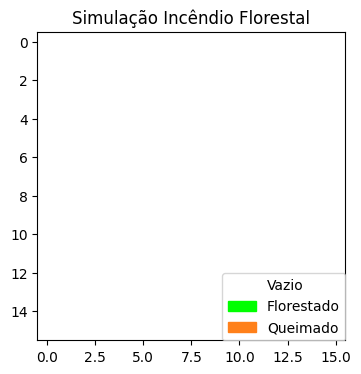

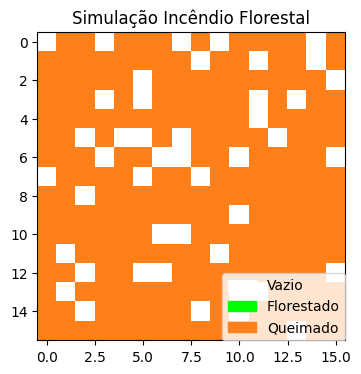

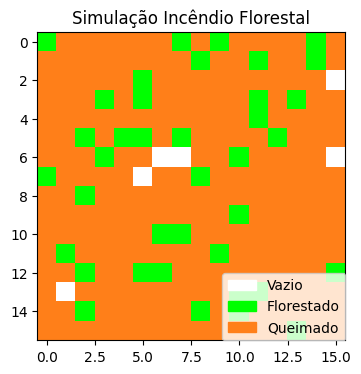

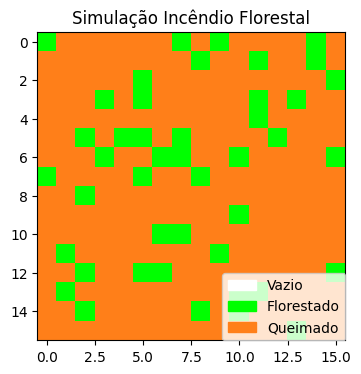

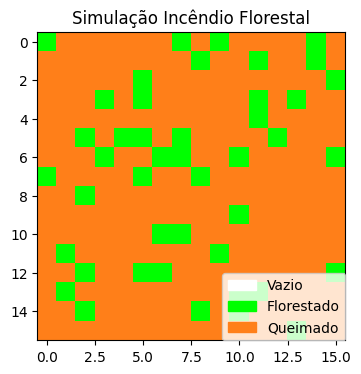

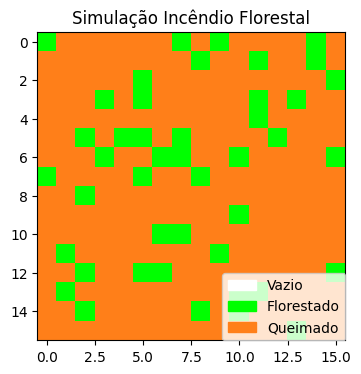

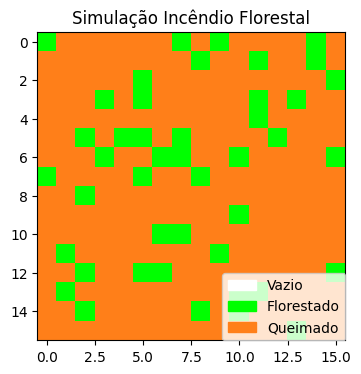

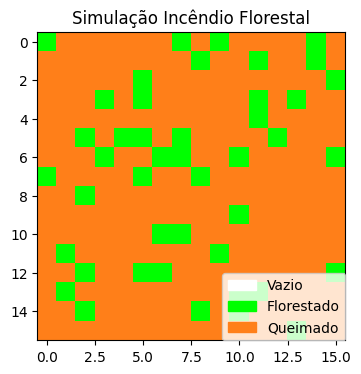

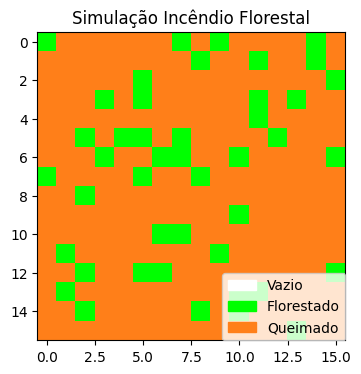

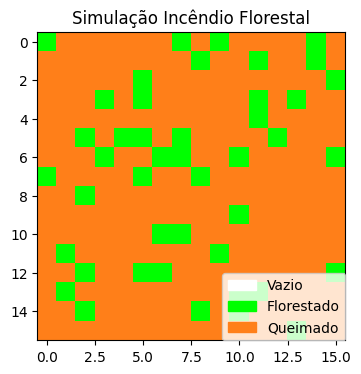

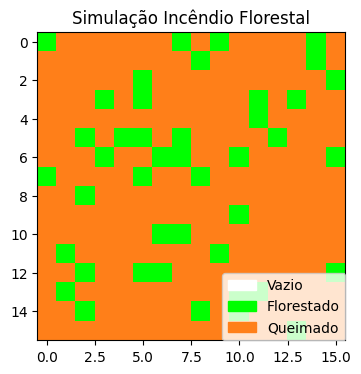

[211, 1, 0, 0, 0, 0, 0, 0, 0, 1]

In [ ]:
simular(
    quantidadeSimulacoes = 10,
    tamanho = 256,
    probabilidadeCrescerArvore = 0.8,
    probabilidadeQuedaRaio = 0.2,
    devePlotar = True
)

#### Crescimento baixo e queda de raio alta
---

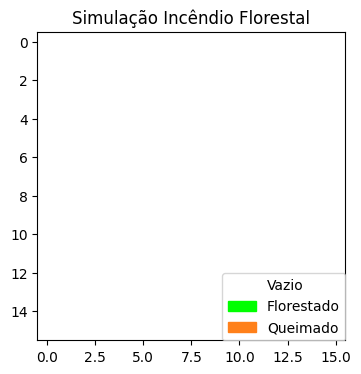

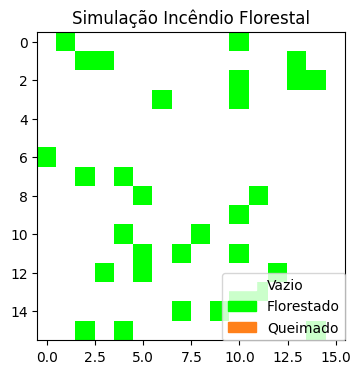

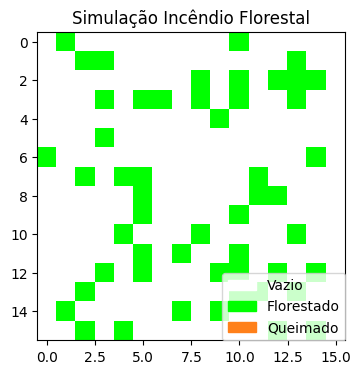

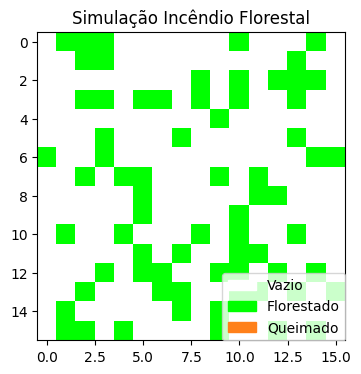

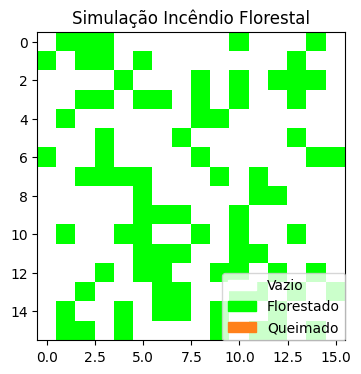

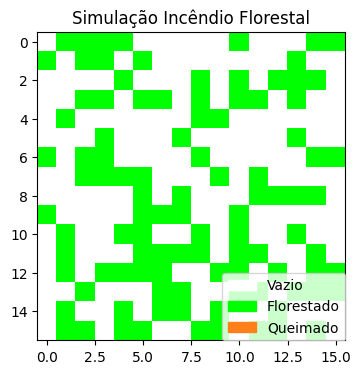

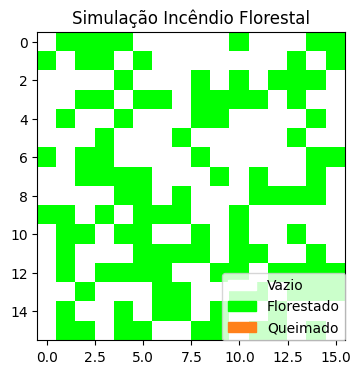

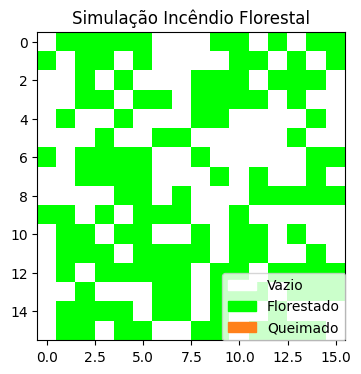

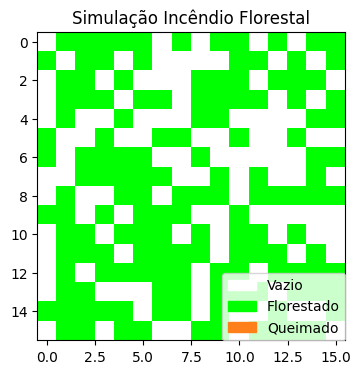

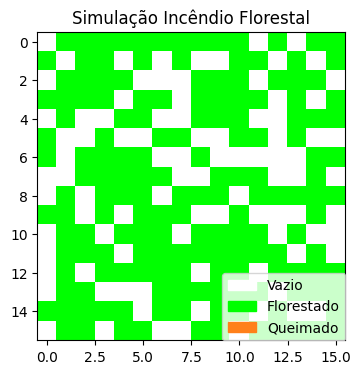

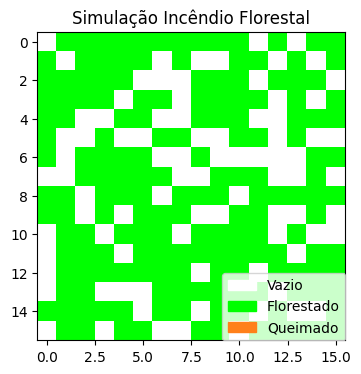

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [ ]:
simular(
    quantidadeSimulacoes = 10,
    tamanho = 256,
    probabilidadeCrescerArvore = 0.1,
    probabilidadeQuedaRaio = 0.8,
    devePlotar = True
)

#### Crescimento e queda de raio altas
---

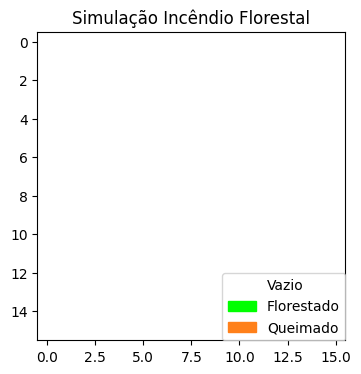

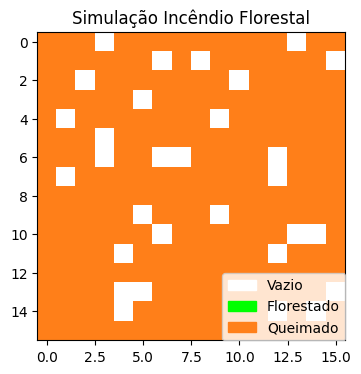

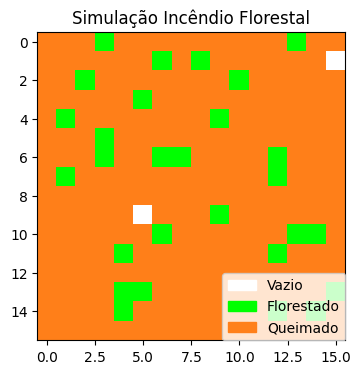

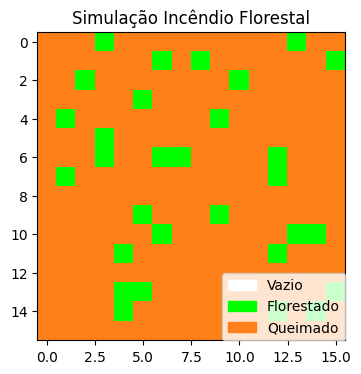

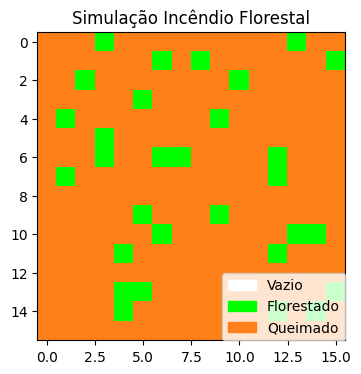

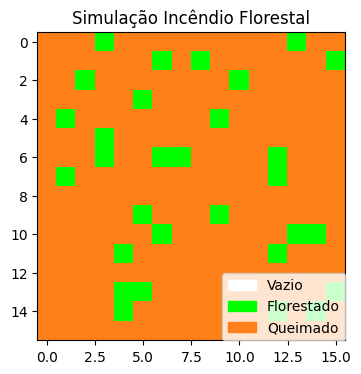

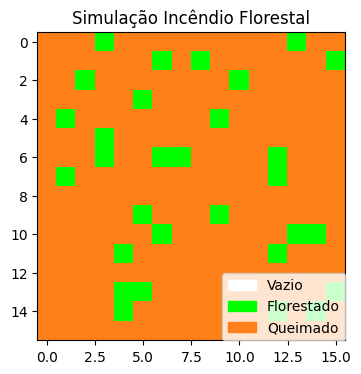

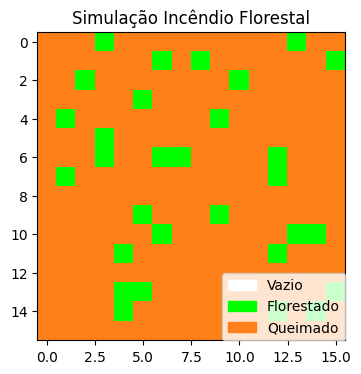

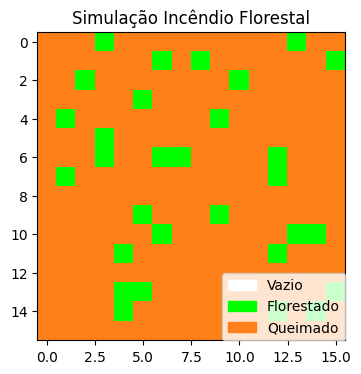

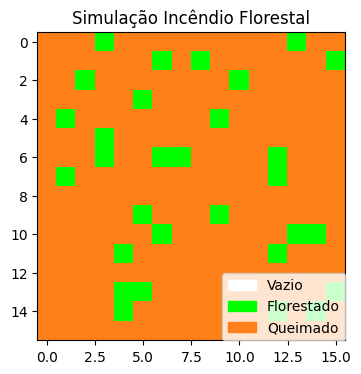

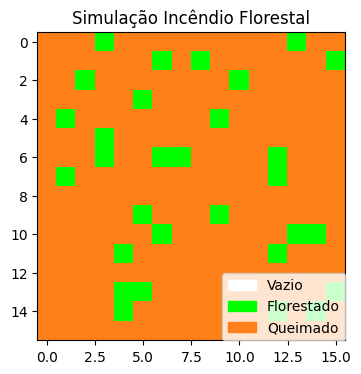

[226, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [ ]:
simular(
    quantidadeSimulacoes = 10,
    tamanho = 256,
    probabilidadeCrescerArvore = 0.9,
    probabilidadeQuedaRaio = 0.8,
    devePlotar = True
)

In [ ]:
def realizarMultiplasSimulacoes(
    quantidadeSimulacoes: int,
    quantidadePassos: int,
    tamanho: int,
    probabilidadeCrescerArvore: float,
    probabilidadeQuedaRaio: float
  ) -> None:

  resultados: list[int] = []

  for i in range(quantidadeSimulacoes):
    resultadoSimulacao = simular(
      quantidadePassos,
      tamanho,
      probabilidadeCrescerArvore,
      probabilidadeQuedaRaio,
      devePlotar = False
    )

    resultados = resultados + resultadoSimulacao

  resultados = [i for i in resultados if i != 0]
  return {
      "listaQuantidadeArvoresQueimadasPorRaio": resultados,
      "totalArvoresQueimadas": np.sum(resultados)
  }

## Histograma de queimadas com multiplas simulações
---

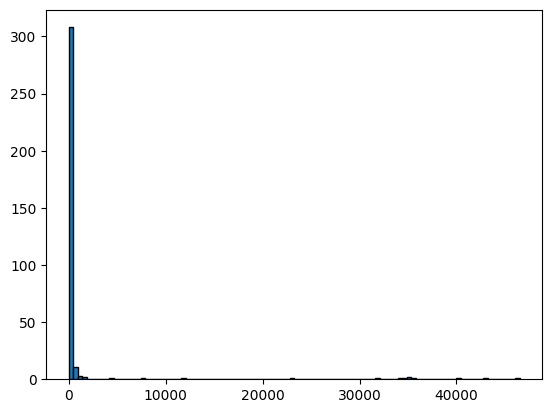

In [ ]:
resultados = realizarMultiplasSimulacoes(
    quantidadeSimulacoes = 10,
    quantidadePassos = 104,
    tamanho = 65536,
    probabilidadeCrescerArvore = 0.1,
    probabilidadeQuedaRaio = 0.2
)

plt.hist(resultados["listaQuantidadeArvoresQueimadasPorRaio"], bins = 100, edgecolor = 'black', density = False)
plt.show()

## Histograma queimadas com floresta pequena
---

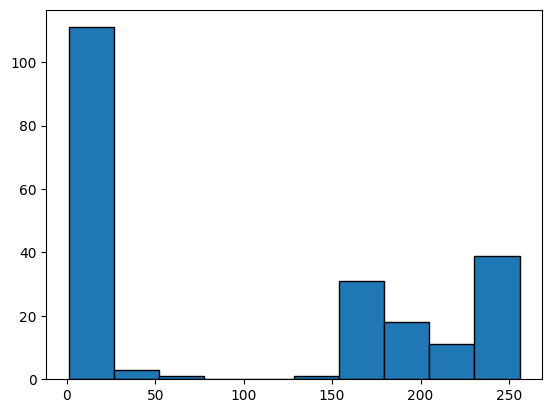

In [ ]:
resultados = realizarMultiplasSimulacoes(
    quantidadeSimulacoes = 100,
    quantidadePassos = 10,
    tamanho = 256,
    probabilidadeCrescerArvore = 0.7,
    probabilidadeQuedaRaio = 0.2
)

plt.hist(resultados["listaQuantidadeArvoresQueimadasPorRaio"], bins = 10, edgecolor = 'black', density = False)
plt.show()

## Histograma de queimadas grandes
---

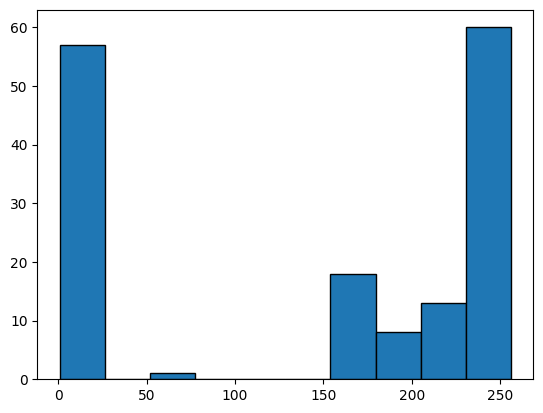

In [ ]:
resultados = realizarMultiplasSimulacoes(
    quantidadeSimulacoes = 100,
    quantidadePassos = 10,
    tamanho = 256,
    probabilidadeCrescerArvore = 0.7,
    probabilidadeQuedaRaio = 0.5
)

plt.hist(resultados["listaQuantidadeArvoresQueimadasPorRaio"], bins = 10, edgecolor = 'black', density = False)
plt.show()

É possível notar que queimadas pequenas são muito mais frequentes que queimadas grandes, tanto em florestas pequenas, quanto em florestas grandes. A menos que os parâmetros sejam específicos, as queimadas grandes tendem a ser mais raras.